In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("/Users/amnzghaffar/Desktop/Data Institute/Mini project 1/lung_cancer_dataset.csv")  # <-- change file name if needed
df.head()


,patient_id,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
0,100000,69,Male,66.025244,High,No,No,Yes,Moderate,No,No
1,100001,32,Female,12.780800,High,No,Yes,Yes,Moderate,Yes,Yes
2,100002,89,Female,0.408278,Medium,Yes,Yes,Yes,NaN,No,Yes
3,100003,78,Female,44.065232,Low,No,Yes,No,Moderate,No,Yes
4,100004,38,Female,44.432440,Medium,Yes,No,Yes,NaN,Yes,Yes


In [4]:
print("Shape:", df.shape)
display(df.head())
display(df.tail())
df.info()


Shape: (50000, 11)


,patient_id,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
0,100000,69,Male,66.025244,High,No,No,Yes,Moderate,No,No
1,100001,32,Female,12.780800,High,No,Yes,Yes,Moderate,Yes,Yes
2,100002,89,Female,0.408278,Medium,Yes,Yes,Yes,NaN,No,Yes
3,100003,78,Female,44.065232,Low,No,Yes,No,Moderate,No,Yes
4,100004,38,Female,44.432440,Medium,Yes,No,Yes,NaN,Yes,Yes


,patient_id,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
49995,149995,81,Female,9.386431,Medium,No,Yes,No,Moderate,No,Yes
49996,149996,28,Male,99.471718,Medium,No,Yes,No,Moderate,No,Yes
49997,149997,90,Male,14.349722,Low,Yes,Yes,No,Heavy,Yes,Yes
49998,149998,33,Female,87.012555,Medium,No,No,Yes,Moderate,No,No
49999,149999,31,Male,37.596851,Low,No,No,Yes,NaN,Yes,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 50000 non-null  int64  
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   pack_years                 50000 non-null  float64
 4   radon_exposure             50000 non-null  object 
 5   asbestos_exposure          50000 non-null  object 
 6   secondhand_smoke_exposure  50000 non-null  object 
 7   copd_diagnosis             50000 non-null  object 
 8   alcohol_consumption        33338 non-null  object 
 9   family_history             50000 non-null  object 
 10  lung_cancer                50000 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 4.2+ MB


In [5]:
df.columns = df.columns.str.strip().str.lower()
df.columns


Index(['patient_id', 'age', 'gender', 'pack_years', 'radon_exposure',
       'asbestos_exposure', 'secondhand_smoke_exposure', 'copd_diagnosis',
       'alcohol_consumption', 'family_history', 'lung_cancer'],
      dtype='object')

In [6]:
df = df.replace({
    'Yes': 1, 'No': 0,
    'YES': 1, 'NO': 0
})

df.head()


/var/folders/z0/0d97ds5d1rndmfbdzzz54k9c0000gn/T/ipykernel_11133/1498155499.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({


,patient_id,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
0,100000,69,Male,66.025244,High,0,0,1,Moderate,0,0
1,100001,32,Female,12.780800,High,0,1,1,Moderate,1,1
2,100002,89,Female,0.408278,Medium,1,1,1,NaN,0,1
3,100003,78,Female,44.065232,Low,0,1,0,Moderate,0,1
4,100004,38,Female,44.432440,Medium,1,0,1,NaN,1,1


In [7]:
df['alcohol_consumption'] = df['alcohol_consumption'].fillna('Unknown')


In [8]:
risk_features = [
    'radon_exposure',
    'asbestos_exposure',
    'secondhand_smoke_exposure',
    'copd_diagnosis',
    'family_history'
]


In [11]:
# -------------------------------------------------------
# STEP 1: Convert categorical risk features into numbers
# -------------------------------------------------------
# Why?
# Risk features are stored as text (Yes/No, Low/Medium/High).
# To calculate a risk score, we must convert them to numeric values.

# Mapping exposure intensity to numeric scale
level_map = {'Low': 1, 'Medium': 2, 'High': 3}

# Mapping binary Yes/No values to 1/0
yesno_map = {'Yes': 1, 'No': 0}

# Apply mappings to each risk feature
for col in risk_features:
    if df[col].dtype == 'object':
        # First try Low/Medium/High mapping,
        # then apply Yes/No mapping for binary features
        df[col] = df[col].map(level_map).fillna(df[col].map(yesno_map))

# Any remaining missing values are treated as zero risk
# This avoids dropping rows and keeps the dataset intact
df[risk_features] = df[risk_features].fillna(0).astype(int)


# -------------------------------------------------------
# STEP 2: Create the Lung Cancer Risk Score
# -------------------------------------------------------
# Why?
# The risk score provides a simple, explainable summary
# of multiple exposure and symptom factors.
# Higher score = higher cumulative risk.

df['risk_score'] = df[risk_features].sum(axis=1)

# View result
df[['risk_score', 'lung_cancer']].head()


,risk_score,lung_cancer
0,4,0
1,6,1
2,5,1
3,2,1
4,5,1


In [12]:
# -------------------------------------------------------
# STEP 3: Categorise Risk Score into Risk Levels
# -------------------------------------------------------
# Why?
# Stakeholders understand categories better than raw numbers.
# Risk levels help prioritise screening and awareness efforts.

df['risk_level'] = pd.cut(
    df['risk_score'],
    bins=[-1, 2, 4, df['risk_score'].max()],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

df[['risk_score', 'risk_level', 'lung_cancer']].head()


,risk_score,risk_level,lung_cancer
0,4,Medium Risk,0
1,6,High Risk,1
2,5,High Risk,1
3,2,Low Risk,1
4,5,High Risk,1


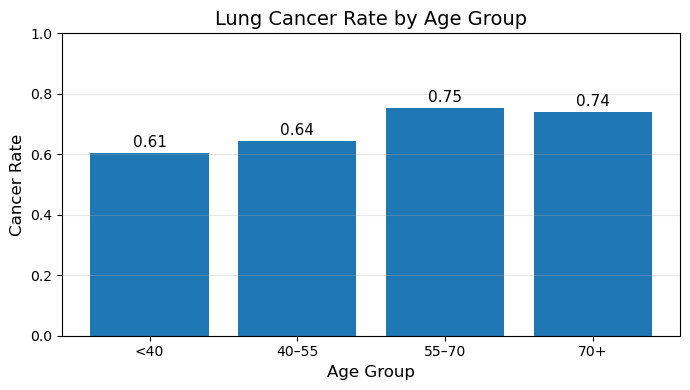

,age_group,lung_cancer
0,<40,0.605749
1,40–55,0.643591
2,55–70,0.753432
3,70+,0.739693


In [19]:
# -------------------------------------------------------
# GRAPH 1: Lung Cancer Rate by Age Group
# -------------------------------------------------------
# Why this graph?
# Governments include age criteria in lung cancer screening
# because cancer risk increases with age due to cumulative
# exposure and biological susceptibility.

import matplotlib.pyplot as plt

# Create age groups relevant to screening logic
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 40, 55, 70, 100],
    labels=['<40', '40–55', '55–70', '70+']
)

# Calculate lung cancer rate in each age group
age_summary = (
    df.groupby('age_group', observed=True)['lung_cancer']
      .mean()
      .reset_index()
)

# Plot
plt.figure(figsize=(7,4))
plt.bar(age_summary['age_group'].astype(str), age_summary['lung_cancer'])
plt.title('Lung Cancer Rate by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Cancer Rate', fontsize=12)
plt.ylim(0, 1)

# Add values on bars for clarity
for i, v in enumerate(age_summary['lung_cancer']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

age_summary


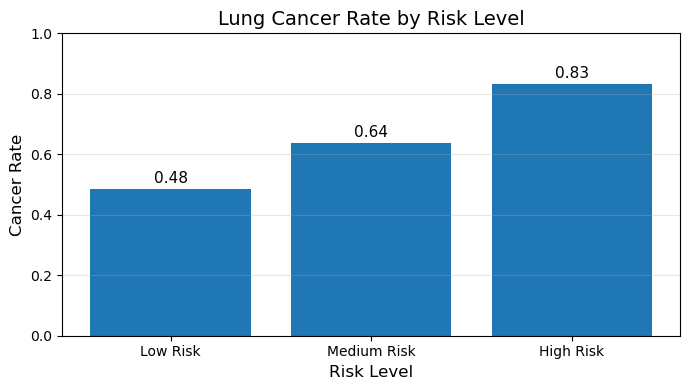

,risk_level,lung_cancer
0,Low Risk,0.484385
1,Medium Risk,0.638672
2,High Risk,0.831175


In [20]:
# -------------------------------------------------------
# GRAPH 2: Lung Cancer Rate by Risk Level
# -------------------------------------------------------
# Why this graph?
# Governments use risk-based criteria for screening
# because cancer risk is concentrated in high-risk groups,
# making targeted screening more effective and efficient.

import matplotlib.pyplot as plt

# Ensure correct order for presentation
order = ['Low Risk', 'Medium Risk', 'High Risk']
df['risk_level'] = pd.Categorical(df['risk_level'], categories=order, ordered=True)

# Calculate cancer rate by risk level
risk_summary = (
    df.groupby('risk_level', observed=True)['lung_cancer']
      .mean()
      .reset_index()
)

# Plot
plt.figure(figsize=(7,4))
plt.bar(risk_summary['risk_level'].astype(str), risk_summary['lung_cancer'])
plt.title('Lung Cancer Rate by Risk Level', fontsize=14)
plt.xlabel('Risk Level', fontsize=12)
plt.ylabel('Cancer Rate', fontsize=12)
plt.ylim(0, 1)

# Add values on bars
for i, v in enumerate(risk_summary['lung_cancer']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

risk_summary


/var/folders/z0/0d97ds5d1rndmfbdzzz54k9c0000gn/T/ipykernel_11133/94465822.py:25: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(


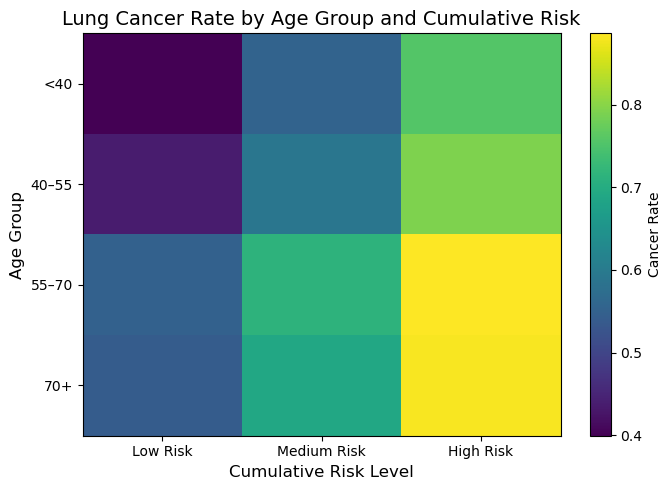

risk_level,Low Risk,Medium Risk,High Risk
age_group,,,
<40,0.399306,0.553523,0.755574
40–55,0.435688,0.591187,0.792523
55–70,0.549612,0.713700,0.886256
70+,0.540747,0.691521,0.882446


In [22]:
# -------------------------------------------------------
# GRAPH 3: Combined Effect of Age Group and Cumulative Risk
# -------------------------------------------------------
# Why this graph?
# Government screening decisions are based on BOTH age
# and the accumulation of multiple risk factors.
# This heatmap shows where lung cancer risk is highest
# when these two dimensions intersect.

import matplotlib.pyplot as plt
import numpy as np

# Ensure age groups are defined
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 40, 55, 70, 100],
    labels=['<40', '40–55', '55–70', '70+']
)

# Ensure correct ordering of risk levels
risk_order = ['Low Risk', 'Medium Risk', 'High Risk']
df['risk_level'] = pd.Categorical(df['risk_level'], categories=risk_order, ordered=True)

# Create pivot table: cancer rate by age group and risk level
heatmap_data = df.pivot_table(
    values='lung_cancer',
    index='age_group',
    columns='risk_level',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(7,5))
plt.imshow(heatmap_data, aspect='auto')
plt.colorbar(label='Cancer Rate')

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns.astype(str)
)
plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index.astype(str)
)

plt.title('Lung Cancer Rate by Age Group and Cumulative Risk', fontsize=14)
plt.xlabel('Cumulative Risk Level', fontsize=12)
plt.ylabel('Age Group', fontsize=12)

plt.tight_layout()
plt.show()

heatmap_data


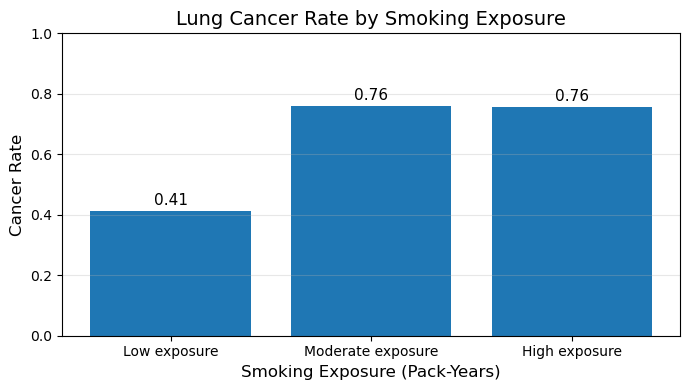

,smoking_group,lung_cancer
0,Low exposure,0.411315
1,Moderate exposure,0.759128
2,High exposure,0.756195


In [23]:
# -------------------------------------------------------
# GRAPH 4: Smoking Exposure vs Lung Cancer Rate
# -------------------------------------------------------
# Why this graph?
# Smoking is the strongest individual risk factor for lung cancer
# and is a key eligibility criterion in screening programs.
# This graph shows how lung cancer prevalence changes
# with different levels of smoking exposure.

import matplotlib.pyplot as plt

# Calculate cancer rate by smoking exposure (pack_years)
# First create smoking exposure groups
df['smoking_group'] = pd.cut(
    df['pack_years'],
    bins=[-1, 0, 20, 40, 1000],
    labels=['Non-smoker', 'Low exposure', 'Moderate exposure', 'High exposure']
)

smoking_summary = (
    df.groupby('smoking_group', observed=True)['lung_cancer']
      .mean()
      .reset_index()
)

# Plot
plt.figure(figsize=(7,4))
plt.bar(smoking_summary['smoking_group'].astype(str), smoking_summary['lung_cancer'])
plt.title('Lung Cancer Rate by Smoking Exposure', fontsize=14)
plt.xlabel('Smoking Exposure (Pack-Years)', fontsize=12)
plt.ylabel('Cancer Rate', fontsize=12)
plt.ylim(0, 1)

# Add values on bars
for i, v in enumerate(smoking_summary['lung_cancer']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

smoking_summary


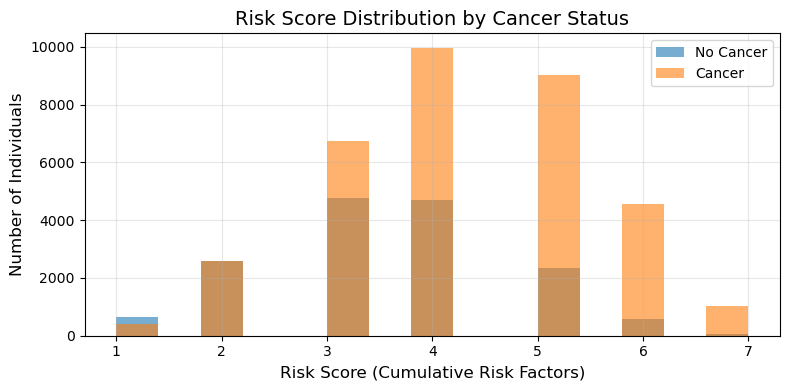

In [24]:
# -------------------------------------------------------
# GRAPH 5: Risk Score Distribution (Cancer vs No Cancer)
# -------------------------------------------------------
# Why this graph?
# Shows how risk scores are distributed in the population,
# and whether lung cancer cases cluster at higher risk scores.
# This supports targeted screening based on cumulative risk.

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

# No cancer group
plt.hist(
    df[df['lung_cancer'] == 0]['risk_score'],
    bins=15,
    alpha=0.6,
    label='No Cancer'
)

# Cancer group
plt.hist(
    df[df['lung_cancer'] == 1]['risk_score'],
    bins=15,
    alpha=0.6,
    label='Cancer'
)

plt.title('Risk Score Distribution by Cancer Status', fontsize=14)
plt.xlabel('Risk Score (Cumulative Risk Factors)', fontsize=12)
plt.ylabel('Number of Individuals', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


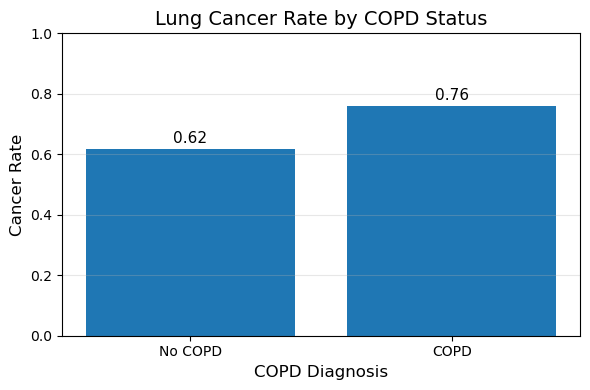

,copd_diagnosis,lung_cancer
0,No COPD,0.615906
1,COPD,0.758278


In [25]:
# -------------------------------------------------------
# GRAPH 6: COPD Diagnosis vs Lung Cancer Rate
# -------------------------------------------------------
# Why this graph?
# Pre-existing lung diseases like COPD increase
# vulnerability to lung cancer.
# Screening programs often prioritise such individuals.

import matplotlib.pyplot as plt

# Calculate cancer rate by COPD diagnosis
copd_summary = (
    df.groupby('copd_diagnosis', observed=True)['lung_cancer']
      .mean()
      .reset_index()
)

# Convert labels for readability
copd_summary['copd_diagnosis'] = copd_summary['copd_diagnosis'].map({
    0: 'No COPD',
    1: 'COPD'
})

# Plot
plt.figure(figsize=(6,4))
plt.bar(copd_summary['copd_diagnosis'], copd_summary['lung_cancer'])
plt.title('Lung Cancer Rate by COPD Status', fontsize=14)
plt.xlabel('COPD Diagnosis', fontsize=12)
plt.ylabel('Cancer Rate', fontsize=12)
plt.ylim(0, 1)

# Add values on bars
for i, v in enumerate(copd_summary['lung_cancer']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

copd_summary


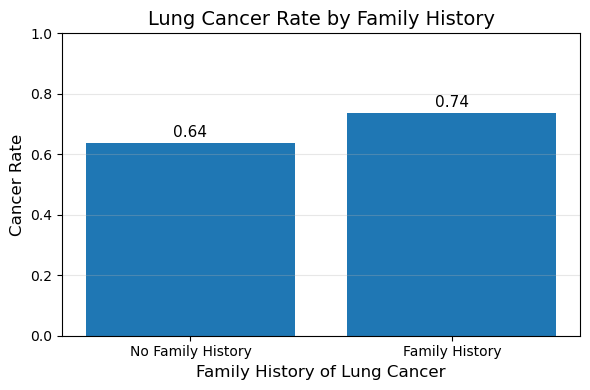

,family_history,lung_cancer
0,No Family History,0.637766
1,Family History,0.736861


In [26]:
# -------------------------------------------------------
# GRAPH 7: Family History vs Lung Cancer Rate
# -------------------------------------------------------
# Why this graph?
# Family history reflects genetic susceptibility.
# Screening programs consider it as an additional
# risk-enhancing factor when deciding eligibility.

import matplotlib.pyplot as plt

# Calculate cancer rate by family history
family_summary = (
    df.groupby('family_history', observed=True)['lung_cancer']
      .mean()
      .reset_index()
)

# Convert labels for readability
family_summary['family_history'] = family_summary['family_history'].map({
    0: 'No Family History',
    1: 'Family History'
})

# Plot
plt.figure(figsize=(6,4))
plt.bar(family_summary['family_history'], family_summary['lung_cancer'])
plt.title('Lung Cancer Rate by Family History', fontsize=14)
plt.xlabel('Family History of Lung Cancer', fontsize=12)
plt.ylabel('Cancer Rate', fontsize=12)
plt.ylim(0, 1)

# Add values on bars
for i, v in enumerate(family_summary['lung_cancer']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

family_summary


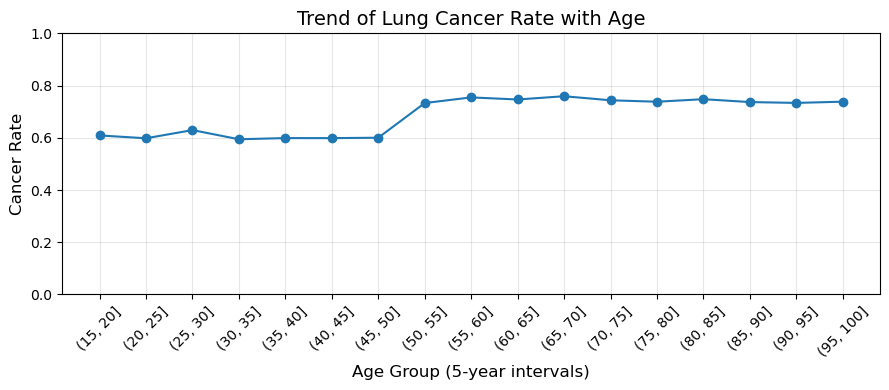

,age_bin,lung_cancer
0,"(15, 20]",0.609056
1,"(20, 25]",0.598140
2,"(25, 30]",0.629437
3,"(30, 35]",0.594403
4,"(35, 40]",0.598861


In [27]:
# -------------------------------------------------------
# LINE GRAPH: Lung Cancer Rate Trend with Age
# -------------------------------------------------------
# Why this graph?
# Age is a continuous variable, and this line graph
# shows how lung cancer risk increases as age increases.
# This supports age-based screening thresholds.

import matplotlib.pyplot as plt

# Create age bins (smaller bins for smoother trend)
df['age_bin'] = pd.cut(
    df['age'],
    bins=range(0, 101, 5)  # 5-year age intervals
)

# Calculate cancer rate for each age bin
age_trend = (
    df.groupby('age_bin', observed=True)['lung_cancer']
      .mean()
      .reset_index()
)

# Convert age_bin to string for plotting
age_trend['age_bin'] = age_trend['age_bin'].astype(str)

# Plot line graph
plt.figure(figsize=(9,4))
plt.plot(age_trend['age_bin'], age_trend['lung_cancer'], marker='o')

plt.title('Trend of Lung Cancer Rate with Age', fontsize=14)
plt.xlabel('Age Group (5-year intervals)', fontsize=12)
plt.ylabel('Cancer Rate', fontsize=12)
plt.ylim(0, 1)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

age_trend.head()
